# Country-by-country quarterly OLS coefficients against shock-weighted $\xi$

This notebook runs separate time-series OLS regressions for each country using quarterly data.

Configurable elements:

- `plot_horizons`: the CPI horizons to estimate and plot
- `y_lags = 3`
- `shock_lags = 3`
- optional lagged macro controls only, with 3 lags and no contemporaneous controls

For `h = 0`, the regression uses quarterly CPI on quarterly oil.
For `h > 0`, the regression uses cumulative CPI on cumulative oil, summing from `t` through `t+h` in the same spirit as the panel cumulative notebooks.
Lag terms remain lags of the underlying quarterly CPI and quarterly oil series.

For each country, the plot x-axis is the shock-weighted exposure measure

$$\tilde{\xi}_m = \frac{\sum_t \xi_{m,t} u_t^2}{\sum_t u_t^2}$$

where $u_t = \text{oil\_pct\_change}_t$, computed over that country's regression sample.


In [81]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import statsmodels.api as sm

ROOT = Path.cwd().resolve()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent

for path in [ROOT, ROOT / "src"]:
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

import local_projections as lp


In [82]:
xi_path = ROOT / "data/processed/xi/regular/xi_by_country_year.parquet"
cpi_path = ROOT / "data/processed/cpi/quarterly_cpi.csv"
oil_path = ROOT / "data/processed/oil/quarterly_oil.csv"

panel_controls = [
    {
        "name": "exchange_rate",
        "path": ROOT / "data/processed/exchange_rates/quarterly_exchange_rates.csv",
        "value_column": "log_diff",
        "merge_keys": ["country", "period"],
        "merge_key_columns": {"country": "country_code", "period": "quarter"},
        "status_column": None,
    },
    {
        "name": "output_gap",
        "path": ROOT / "data/processed/real_gdp/quarterly_output_gap.csv",
        "value_column": "output_gap",
        "merge_keys": ["country", "period"],
        "status_column": "hp_filter_status",
        "ok_status": "ok",
    },
    {
        "name": "policy_rate",
        "path": ROOT / "data/processed/policy_rates/quarterly_policy_rates.csv",
        "value_column": "policy_rate",
        "merge_keys": ["country", "period"],
        "merge_key_columns": {"period": "quarter"},
        "status_column": None,
    },
]

macro_controls = ["exchange_rate", "output_gap", "policy_rate"]
exclude_countries = ["AGO", "ARE", "ARG", "BGD", "BGR", "BLR", "BRA", "BRN", "CHN", "CIV", "CMR", "COD", "CYP", "EGY", "HKG", "HRV", "IDN", "IND", "JOR", "KAZ", "KHM", "LAO", "MAR", "MLT", "MMR", "MYS", "NGA", "PAK", "PER", "PHL", "RUS", "SAU", "SEN", "SGP", "STP", "THA", "TUN", "TWN", "UKR", "VNM"]
plot_horizons = [0, 3, 7, 11]
y_lags = 3
shock_lags = 3
control_lags = 3
lag_xi_by_one_year_for_xi_x_oil = True

panel_df = lp.build_panel_lp_dataset(
    xi_path=xi_path,
    cpi_path=cpi_path,
    oil_path=oil_path,
    cpi_freq="Q",
    lag_xi_by_one_year_for_xi_x_oil=lag_xi_by_one_year_for_xi_x_oil,
    controls=panel_controls,
    exclude_countries=exclude_countries,
)

print(f"Panel rows: {len(panel_df):,}")
print(f"Countries: {panel_df['country'].nunique()}")
print(f"Excluded countries: {exclude_countries}")
print(f"Periods: {panel_df['period'].nunique()}")
print(f"Plot horizons: {plot_horizons}")
panel_df.head()


Panel rows: 4,470
Countries: 40
Excluded countries: ['AGO', 'ARE', 'ARG', 'BGD', 'BGR', 'BLR', 'BRA', 'BRN', 'CHN', 'CIV', 'CMR', 'COD', 'CYP', 'EGY', 'HKG', 'HRV', 'IDN', 'IND', 'JOR', 'KAZ', 'KHM', 'LAO', 'MAR', 'MLT', 'MMR', 'MYS', 'NGA', 'PAK', 'PER', 'PHL', 'RUS', 'SAU', 'SEN', 'SGP', 'STP', 'THA', 'TUN', 'TWN', 'UKR', 'VNM']
Periods: 112
Plot horizons: [0, 3, 7, 11]


,country,year,period,time_index,xi,oil_pct_change,xi_x_oil,cpi_pct_change,exchange_rate,output_gap,policy_rate
0,AUS,1995,1995-Q1,7980,0.021698,0.043415,NaN,0.015924,0.008404,-0.002764,7.5
1,AUS,1995,1995-Q2,7981,0.021698,0.051642,NaN,0.014106,0.028409,-0.007747,7.5
2,AUS,1995,1995-Q3,7982,0.021698,-0.097255,NaN,0.012365,-0.017450,0.005223,7.5
3,AUS,1995,1995-Q4,7983,0.021698,0.026433,NaN,0.007634,-0.010554,-0.004938,7.5
4,AUS,1996,1996-Q1,7984,0.024256,0.079017,0.001714,0.003030,-0.010226,0.000280,7.5


In [83]:
def build_country_regression_sample(
    country_df: pd.DataFrame,
    *,
    horizon: int,
    macro_controls: list[str],
    include_lagged_controls: bool,
) -> tuple[pd.DataFrame, str, str, list[str]]:
    if horizon < 0:
        raise ValueError("horizon must be >= 0")

    work = country_df[[
        "country",
        "period",
        "time_index",
        "year",
        "xi",
        "cpi_pct_change",
        "oil_pct_change",
        *macro_controls,
    ]].copy()
    work = work.sort_values("time_index").reset_index(drop=True)

    if horizon == 0:
        dep_col = "cpi_pct_change_h0"
        shock_col = "oil_pct_change_h0"
        work[dep_col] = work["cpi_pct_change"]
        work[shock_col] = work["oil_pct_change"]
    else:
        dep_col = f"cum_cpi_lead{horizon}"
        shock_col = f"cum_oil_lead{horizon}"
        work[dep_col] = 0.0
        work[shock_col] = 0.0
        for step in range(horizon + 1):
            shifted_cpi = work["cpi_pct_change"].shift(-step)
            shifted_oil = work["oil_pct_change"].shift(-step)
            work[dep_col] = shifted_cpi if step == 0 else work[dep_col] + shifted_cpi
            work[shock_col] = shifted_oil if step == 0 else work[shock_col] + shifted_oil

    y_lag_cols = []
    for lag in range(1, y_lags + 1):
        col = f"cpi_pct_change_lag{lag}"
        work[col] = work["cpi_pct_change"].shift(lag)
        y_lag_cols.append(col)

    shock_lag_cols = []
    for lag in range(1, shock_lags + 1):
        col = f"oil_pct_change_lag{lag}"
        work[col] = work["oil_pct_change"].shift(lag)
        shock_lag_cols.append(col)

    control_cols = []
    if include_lagged_controls:
        for control in macro_controls:
            for lag in range(1, control_lags + 1):
                col = f"{control}_lag{lag}"
                work[col] = work[control].shift(lag)
                control_cols.append(col)

    x_cols = [shock_col, *shock_lag_cols, *y_lag_cols]
    if include_lagged_controls:
        x_cols.extend(control_cols)

    work = work.dropna(subset=[dep_col, *x_cols]).copy()
    return work, dep_col, shock_col, x_cols


def compute_shock_weighted_xi(work: pd.DataFrame) -> float:
    weights = work["oil_pct_change"].astype(float) ** 2
    denom = float(weights.sum())
    if denom == 0.0:
        return float("nan")
    return float((work["xi"].astype(float) * weights).sum() / denom)


def run_country_ols(
    df: pd.DataFrame,
    *,
    horizon: int,
    include_lagged_controls: bool,
) -> pd.DataFrame:
    rows = []

    for country, country_df in df.groupby("country"):
        work, dep_col, shock_col, x_cols = build_country_regression_sample(
            country_df,
            horizon=horizon,
            macro_controls=macro_controls,
            include_lagged_controls=include_lagged_controls,
        )
        if work.empty or len(work) <= len(x_cols):
            continue

        y = pd.to_numeric(work[dep_col], errors="coerce")
        x = sm.add_constant(work[x_cols], has_constant="add")
        model = sm.OLS(y, x, missing="raise").fit()

        shock_se = float(model.bse[shock_col])
        weight_inv_var = float(1.0 / (shock_se ** 2)) if shock_se > 0 else float("nan")

        rows.append(
            {
                "country": country,
                "horizon": horizon,
                "nobs": int(model.nobs),
                "shock_col": shock_col,
                "coef_shock": float(model.params[shock_col]),
                "se_shock": shock_se,
                "t_shock": float(model.tvalues[shock_col]),
                "p_shock": float(model.pvalues[shock_col]),
                "r2": float(model.rsquared),
                "xi_weighted": compute_shock_weighted_xi(work),
                "xi_mean": float(work["xi"].mean()),
                "include_lagged_controls": include_lagged_controls,
                "n_regressors_ex_const": len(x_cols),
                "weight_inv_var": weight_inv_var,
            }
        )

    return pd.DataFrame(rows).sort_values(["horizon", "country"]).reset_index(drop=True)


def run_spec_for_horizons(
    df: pd.DataFrame,
    *,
    horizons: list[int],
    include_lagged_controls: bool,
) -> pd.DataFrame:
    parts = []
    for horizon in horizons:
        result = run_country_ols(
            df,
            horizon=horizon,
            include_lagged_controls=include_lagged_controls,
        )
        parts.append(result)
    if not parts:
        return pd.DataFrame()
    return pd.concat(parts, axis=0, ignore_index=True)


def plot_coef_vs_weighted_xi(results: pd.DataFrame, *, title_prefix: str) -> None:
    for horizon in sorted(results["horizon"].unique()):
        horizon_df = results.loc[results["horizon"] == horizon].copy()
        horizon_df = horizon_df.dropna(subset=["xi_weighted", "coef_shock", "se_shock", "weight_inv_var"]).copy()
        fig, ax = plt.subplots(figsize=(10, 7))
        marker_sizes = 40.0 * horizon_df["weight_inv_var"] / horizon_df["weight_inv_var"].median()
        ax.scatter(horizon_df["xi_weighted"], horizon_df["coef_shock"], s=marker_sizes, alpha=0.85)

        for row in horizon_df.itertuples(index=False):
            ax.annotate(
                row.country,
                (row.xi_weighted, row.coef_shock),
                xytext=(4, 4),
                textcoords="offset points",
                fontsize=8,
            )

        fit = sm.WLS(
            horizon_df["coef_shock"],
            sm.add_constant(horizon_df["xi_weighted"], has_constant="add"),
            weights=horizon_df["weight_inv_var"],
        ).fit()
        x_line = pd.Series(sorted(horizon_df["xi_weighted"]))
        x_line_design = sm.add_constant(x_line, has_constant="add")
        prediction = fit.get_prediction(x_line_design).summary_frame(alpha=0.05)
        y_line = prediction["mean"]
        ci_lower = prediction["mean_ci_lower"]
        ci_upper = prediction["mean_ci_upper"]
        ax.plot(x_line, y_line, color="black", linewidth=1.5, linestyle="--")
        ax.fill_between(x_line, ci_lower, ci_upper, color="black", alpha=0.12)
        equation = f"WLS fit: y = {fit.params['const']:.3f} + {fit.params['xi_weighted']:.3f} x"

        ax.axhline(0.0, color="0.6", linewidth=1.0)
        ax.set_ylim(-0.01, 0.1)
        ax.set_xlabel("Shock-weighted xi in the country regression sample")
        shock_label = horizon_df["shock_col"].iloc[0]
        ax.set_ylabel("Country-specific OLS coefficient on shock")
        ax.set_title(f"{title_prefix}, horizon={horizon}, shock={shock_label}")
        ax.text(
            0.02,
            0.98,
            equation,
            transform=ax.transAxes,
            va="top",
            ha="left",
            fontsize=10,
            bbox={"facecolor": "white", "alpha": 0.85, "edgecolor": "0.7"},
        )
        ax.grid(alpha=0.25)
        plt.show()


## Spec 1: No Controls


In [84]:
results_spec1 = run_spec_for_horizons(
    panel_df,
    horizons=plot_horizons,
    include_lagged_controls=False,
)
print(f"Rows estimated: {len(results_spec1)}")
results_spec1.head()


Rows estimated: 160


,country,horizon,nobs,shock_col,coef_shock,se_shock,t_shock,p_shock,r2,xi_weighted,xi_mean,include_lagged_controls,n_regressors_ex_const,weight_inv_var
0,AUS,0,109,oil_pct_change_h0,0.018339,0.003345,5.481869,3.110428e-07,0.296839,0.027059,0.027690,False,7,89357.153578
1,AUT,0,109,oil_pct_change_h0,0.012641,0.002882,4.386549,2.832408e-05,0.474170,0.028507,0.029595,False,7,120420.986060
2,BEL,0,109,oil_pct_change_h0,0.016335,0.002936,5.563730,2.174880e-07,0.511141,0.042332,0.042445,False,7,116011.802932
3,CAN,0,109,oil_pct_change_h0,0.021318,0.002810,7.585658,1.669479e-11,0.525545,0.044754,0.043287,False,7,126612.957339
4,CHE,0,109,oil_pct_change_h0,0.012166,0.002264,5.373254,4.980307e-07,0.593130,0.014439,0.015482,False,7,195061.692985


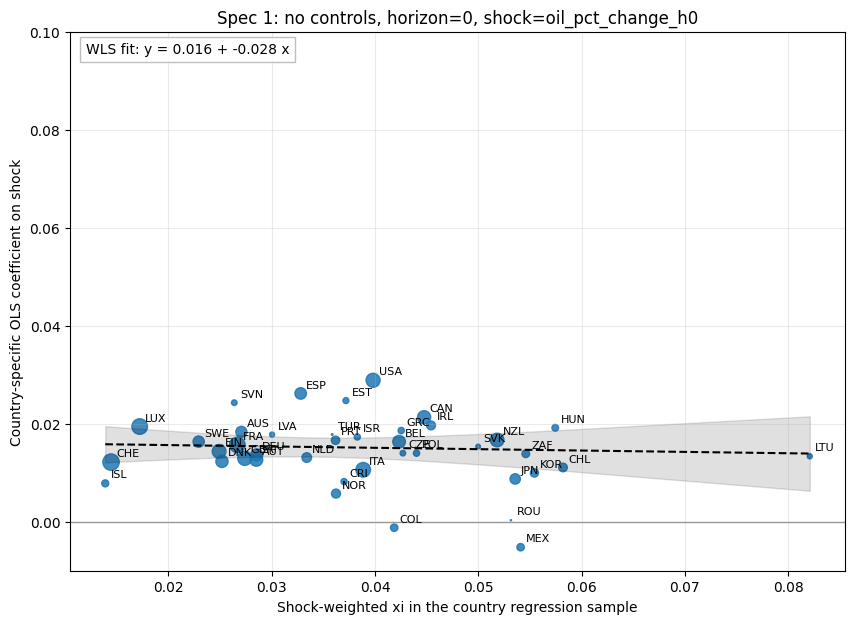

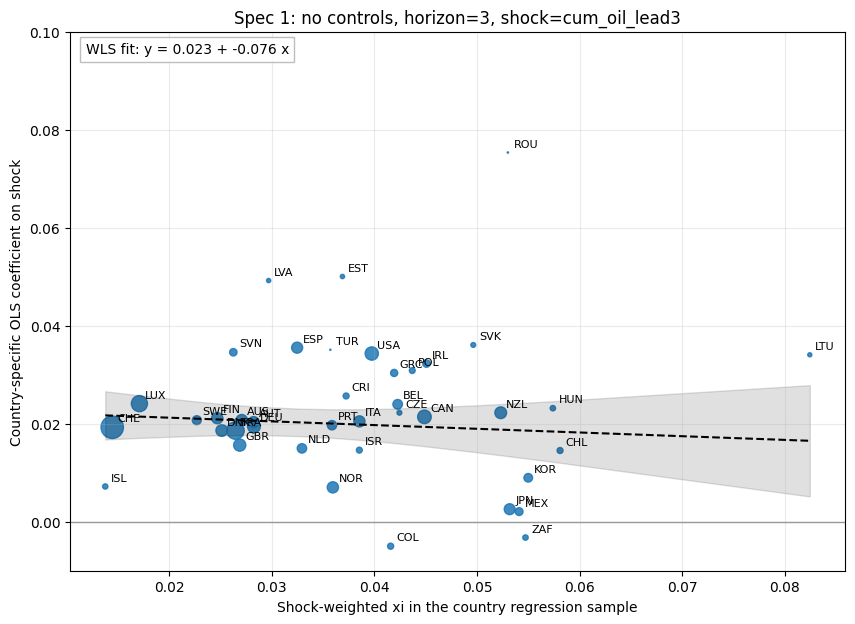

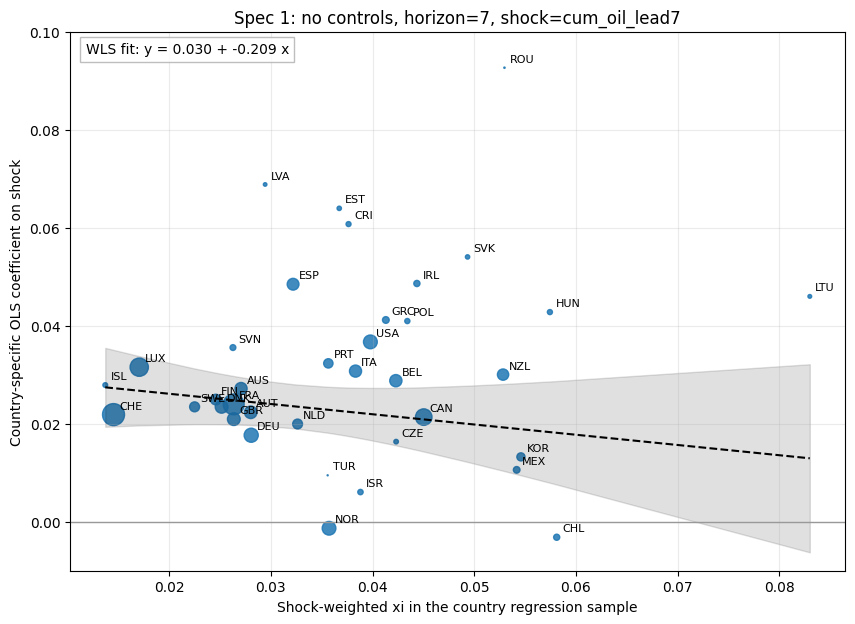

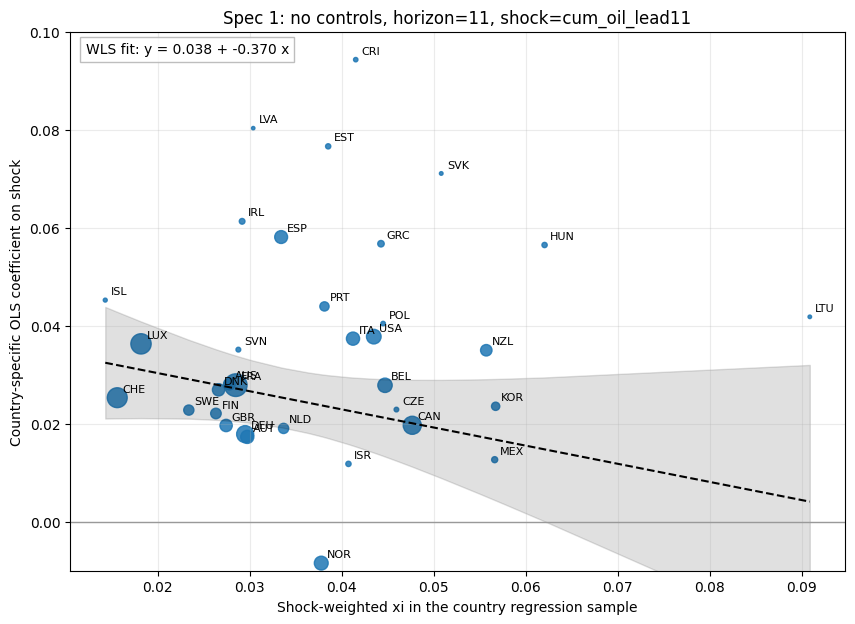

In [85]:
plot_coef_vs_weighted_xi(results_spec1, title_prefix="Spec 1: no controls")


## Spec 2: Lagged Macro Controls Only


In [86]:
results_spec2 = run_spec_for_horizons(
    panel_df,
    horizons=plot_horizons,
    include_lagged_controls=True,
)
print(f"Rows estimated: {len(results_spec2)}")
results_spec2.head()


Rows estimated: 156


,country,horizon,nobs,shock_col,coef_shock,se_shock,t_shock,p_shock,r2,xi_weighted,xi_mean,include_lagged_controls,n_regressors_ex_const,weight_inv_var
0,AUS,0,109,oil_pct_change_h0,0.021320,0.003320,6.421509,5.827070e-09,0.442403,0.027059,0.027690,True,16,90720.766617
1,AUT,0,93,oil_pct_change_h0,0.017173,0.002962,5.796685,1.455142e-07,0.638399,0.029587,0.031128,True,16,113943.369005
2,BEL,0,93,oil_pct_change_h0,0.018059,0.003235,5.583216,3.494379e-07,0.640633,0.043127,0.043399,True,16,95583.631882
3,CAN,0,109,oil_pct_change_h0,0.022690,0.003067,7.396971,6.338433e-11,0.571042,0.044754,0.043287,True,16,106277.312814
4,CHE,0,109,oil_pct_change_h0,0.013392,0.002317,5.779476,1.014817e-07,0.677431,0.014439,0.015482,True,16,186256.511879


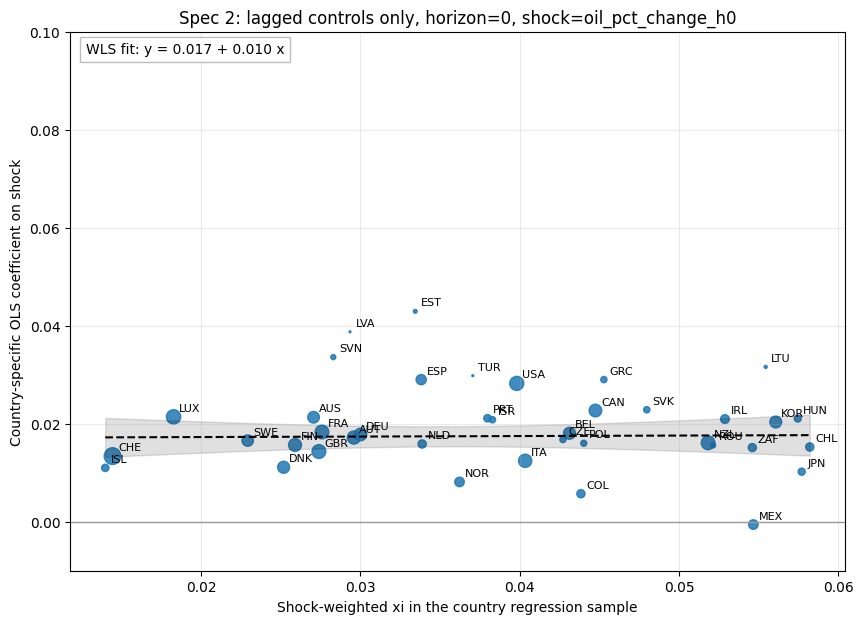

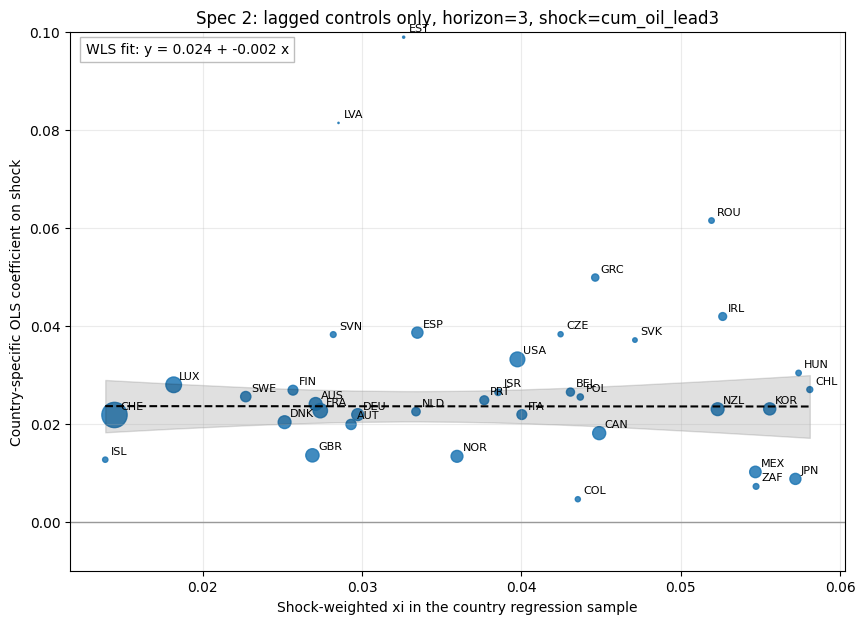

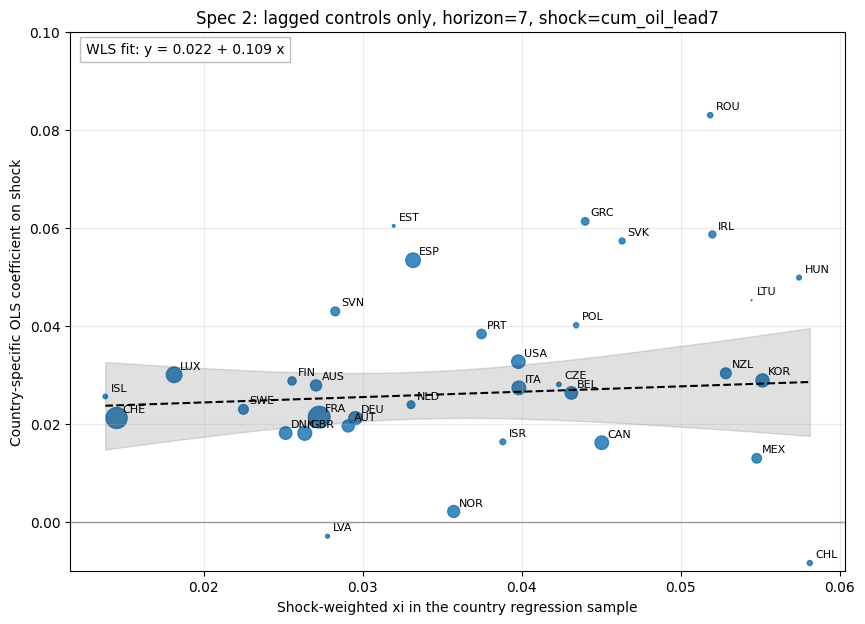

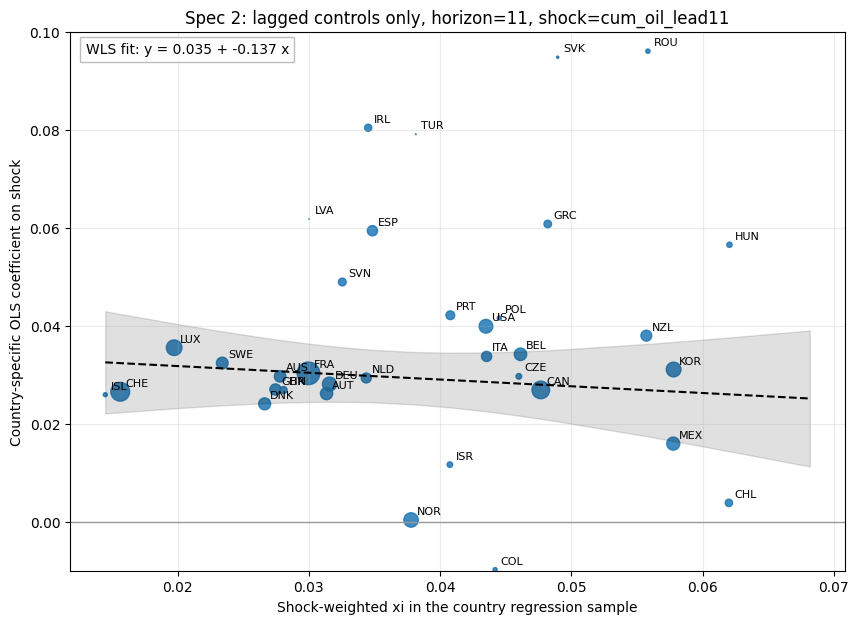

In [87]:
plot_coef_vs_weighted_xi(results_spec2, title_prefix="Spec 2: lagged controls only")


## Comparison Table


In [88]:
comparison_df = (
    results_spec1[["country", "horizon", "shock_col", "coef_shock", "se_shock", "weight_inv_var", "nobs", "xi_weighted"]]
    .rename(columns={
        "shock_col": "shock_col_spec1",
        "coef_shock": "coef_spec1",
        "se_shock": "se_spec1",
        "weight_inv_var": "weight_spec1",
        "nobs": "nobs_spec1",
        "xi_weighted": "xi_weighted_spec1",
    })
    .merge(
        results_spec2[["country", "horizon", "shock_col", "coef_shock", "se_shock", "weight_inv_var", "nobs", "xi_weighted"]].rename(columns={
            "shock_col": "shock_col_spec2",
            "coef_shock": "coef_spec2",
            "se_shock": "se_spec2",
            "weight_inv_var": "weight_spec2",
            "nobs": "nobs_spec2",
            "xi_weighted": "xi_weighted_spec2",
        }),
        on=["country", "horizon"],
        how="outer",
    )
    .sort_values(["horizon", "country"])
    .reset_index(drop=True)
)

comparison_df.head(20)


,country,horizon,shock_col_spec1,coef_spec1,se_spec1,weight_spec1,nobs_spec1,xi_weighted_spec1,shock_col_spec2,coef_spec2,se_spec2,weight_spec2,nobs_spec2,xi_weighted_spec2
0,AUS,0,oil_pct_change_h0,0.018339,0.003345,89357.153578,109,0.027059,oil_pct_change_h0,0.021320,0.003320,90720.766617,109.0,0.027059
1,AUT,0,oil_pct_change_h0,0.012641,0.002882,120420.986060,109,0.028507,oil_pct_change_h0,0.017173,0.002962,113943.369005,93.0,0.029587
2,BEL,0,oil_pct_change_h0,0.016335,0.002936,116011.802932,109,0.042332,oil_pct_change_h0,0.018059,0.003235,95583.631882,93.0,0.043127
3,CAN,0,oil_pct_change_h0,0.021318,0.002810,126612.957339,109,0.044754,oil_pct_change_h0,0.022690,0.003067,106277.312814,109.0,0.044754
4,CHE,0,oil_pct_change_h0,0.012166,0.002264,195061.692985,109,0.014439,oil_pct_change_h0,0.013392,0.002317,186256.511879,109.0,0.014439
5,CHL,0,oil_pct_change_h0,0.011074,0.004292,54285.932277,109,0.058206,oil_pct_change_h0,0.015250,0.004694,45377.644246,100.0,0.058212
6,COL,0,oil_pct_change_h0,-0.001220,0.004986,40220.028080,109,0.041858,oil_pct_change_h0,0.005713,0.004724,44803.216856,69.0,0.043844
7,CRI,0,oil_pct_change_h0,0.008198,0.006022,27571.234321,109,0.037004,NaN,NaN,NaN,NaN,NaN,NaN
8,CZE,0,oil_pct_change_h0,0.013990,0.006639,22690.346567,109,0.042698,oil_pct_change_h0,0.016781,0.006192,26083.740128,105.0,0.042716
9,DEU,0,oil_pct_change_h0,0.013644,0.003054,107189.866676,109,0.028544,oil_pct_change_h0,0.017801,0.003077,105618.713942,93.0,0.030004
